# Applied Machine Learning

## Assignment8 - ShunFai Lee

In [1]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate,KFold
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score,r2_score, adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import neural_network
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.feature_selection import SelectFromModel

In [2]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)

### Question1 and 2:
#### Download and Import of dataset

The dataset "Friday-WorkingHours-Morning.pcap_ISCX" from GeneratedLabelledFlows.zip is chosen and imported.

Check and examine the dataset

In [3]:
#load data set
dataset1 = pd.read_csv("Friday-WorkingHours-Morning.pcap_ISCX.csv")

print("Friday-WorkingHours-Morning.pcap_ISCX.csv")
print(f'total rows_N={len(dataset1)}, features_M={len(dataset1.columns)}\n')
print(dataset1.columns)

# Sanity check
print(f'checking duplicate entries:')
dataset1['duplicate']=dataset1.duplicated()
dup_len = len(dataset1[dataset1['duplicate']==True])
print(f'Number of duplicate: {dup_len}')
if dup_len>0:
    drop_dup(dataset1)
    print(f'Dropped {dup_len} rows for duplicate')
dataset1=dataset1.drop(columns=['duplicate'])    


Friday-WorkingHours-Morning.pcap_ISCX.csv
total rows_N=191033, features_M=85

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Len

Check for null value for each columns

In [4]:
print(f'checking null entries:')
null_stat = dataset1.isnull().sum()
for c in dataset1.columns:
    if null_stat[c]>0:
        print(f'number of null values at {c}: {null_stat[c]}')

checking null entries:
number of null values at Flow Bytes/s: 28


Drop the null entries for it is a small number relative to total rows.

In [5]:
dataset1=dataset1.dropna()

In [6]:
print(f'checking null entries:')
null_stat = dataset1.isnull().sum()
for c in dataset1.columns:
    if null_stat[c]>0:
        print(f'number of null values at {c}: {null_stat[c]}')
print(f'Total rows after removal of null:{len(dataset1)}')

checking null entries:
Total rows after removal of null:191005


Check class labels

In [7]:
print(f"Unique labels of dataset:")
print(dataset1[dataset1.columns[-1]].value_counts())


Unique labels of dataset:
 Label
BENIGN    189039
Bot         1966
Name: count, dtype: int64


In [8]:
print('Number of each type of features:')
print(dataset1.dtypes.value_counts())
non_num_cols = dataset1.columns[dataset1.dtypes=='str']

print('\nexample values at each non-numeric features:')
for col in non_num_cols:
    print(f'{col}:{dataset1[col].iloc[0]}')

Number of each type of features:
int64      43
float64    37
str         5
Name: count, dtype: int64

example values at each non-numeric features:
Flow ID:192.168.10.3-192.168.10.50-3268-56108-6
 Source IP:192.168.10.50
 Destination IP:192.168.10.3
 Timestamp:7/7/2017 8:59
 Label:BENIGN


### Question1 and 2:

As shown from above, this dataset contains 191005 number of rows and 84 features and 1 label column, at the last column. Among all features, 80 are numeric and 4 are string, namely Flow ID, Source IP, Destination IP and Timestamp.

And there are altogether 2 unique labels in this dataset, 'BENIGN' and 'Bot' and the count of the two labels are very unbalanced, with almost 99% being "BENIGN" and only 1 % "Bot"

### Question 3

####  machine learning methodology

look at the ranges of values at different features

In [9]:
num_cols = dataset1.columns[dataset1.dtypes!='str']
value_ranges = {c:{'min':dataset1[c].min(),'max':dataset1[c].max()} for c in num_cols}
for k in value_ranges:
    print(f'{k:30}, min:{value_ranges[k]['min']:15.3f}, max:{value_ranges[k]['max']:15.3f}')

 Source Port                  , min:          0.000, max:      65535.000
 Destination Port             , min:          0.000, max:      64948.000
 Protocol                     , min:          0.000, max:         17.000
 Flow Duration                , min:        -12.000, max:  119999993.000
 Total Fwd Packets            , min:          1.000, max:     207964.000
 Total Backward Packets       , min:          0.000, max:     284602.000
Total Length of Fwd Packets   , min:          0.000, max:    1235152.000
 Total Length of Bwd Packets  , min:          0.000, max:  627000000.000
 Fwd Packet Length Max        , min:          0.000, max:      24820.000
 Fwd Packet Length Min        , min:          0.000, max:       2325.000
 Fwd Packet Length Mean       , min:          0.000, max:       5940.857
 Fwd Packet Length Std        , min:          0.000, max:       7049.469
Bwd Packet Length Max         , min:          0.000, max:      13032.000
 Bwd Packet Length Min        , min:          0.000

### Question 3:

As shown from examination of dataset in previous questions and above printout, almost all features are numeric. And the last 4 non-numeric features are Flow ID, Source IP, Destination IP and Timestamp. However, Flow ID are identification information. Source IP, Destination IP and Timestamp are numeric but stored in non-numeric format.

Number of features is quite big in this dataset, and the value ranges differ in a large extend. Clustering is not suitable for examining the data. Also, since label is available, supervised learning is not suitable, with some appropriate preprocessing and feature selection. Therefore, instead of feeding the data to a learning algorithm directly, I would choose to use a 2 stage method for this dataset:

1. One-hot-encode some categorical feature if any and scale the features
2. use random forest for finding out importance of features
3. Use the filtered features to train a multilayer neural network to learn the probably non-linear problem because it is capable to deal with a complex decision boundary given the amount of features.

### Question 4:
#### Process the class feature/category to 0 and 1

In [10]:
class_map = {'BENIGN':0,'Bot':1}
dataset1_clean = dataset1.drop(columns=' Label')
dataset1_clean[' Label']=dataset1[' Label'].map(class_map)
print(f"Unique labels of dataset:")
#check balance of class labels again
print(dataset1_clean[dataset1_clean.columns[-1]].value_counts())

Unique labels of dataset:
 Label
0    189039
1      1966
Name: count, dtype: int64


As shown on above printout, there are altogether 2 unique labels in this dataset. 'BENIGN' is encoded as 0 and 'Bot' is encoded as 1 explicitly using a mapping dictionary. 

The count of the two labels are very unbalanced, with almost 99% being "BENIGN" and only 1 % "Bot".

### Question 5

#### Explore Dataset 1 features and encode important ports

Before encoding important ports, it worth to check for illegal inf value in the dataset, as discovered in previous ranges printout. These infinity values are problematic for the model training.

In [11]:
inf_col = []
for c in dataset1_clean.columns:
    inf_rows = dataset1_clean[dataset1_clean[c]==float('inf')]
    label_count = inf_rows[inf_rows.columns[-1]].value_counts()
    inf_count = len(inf_rows)
    if inf_count>0:
        inf_col.append(c)
        print(f'Number of inf at col \"{c}\": {inf_count}')
        print(label_count)

Number of inf at col "Flow Bytes/s": 94
 Label
0    84
1    10
Name: count, dtype: int64
Number of inf at col " Flow Packets/s": 94
 Label
0    84
1    10
Name: count, dtype: int64


Most rows containing **'inf'** has class label of "BENIGN" or 0, drop those rows as the amount of data loss is acceptable, for about 200 rows out of almost 200,000.

In [12]:
dataset1_clean = dataset1_clean[~dataset1_clean.isin([float('inf'), float('-inf')]).any(axis=1)]

print(f'Number of rows after clean-up: {len(dataset1_clean)}')


Number of rows after clean-up: 190911


Cleaned up dataset1 now has 190911 rows. Afterwards, I would look at features that are integer, but not float, because they might be categorical data.

In [13]:
dataset1_clean.columns[dataset1_clean.dtypes=='int']

Index([' Source Port', ' Destination Port', ' Protocol', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', ' Min Packet Length', ' Max Packet Length',
       'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count',
       ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count',
       ' CWE Flag Count', ' ECE Flag Count', ' Down/Up Ratio',
       ' Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk',
       ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk',
       'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', ' Subflow Fwd Bytes',
       ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward',
       ' Init_Win_bytes_backward', ' act_dat

Examine the values of Protocal, and Source Port and Destination Port

In [14]:
Protocol_unique = dataset1_clean[' Protocol'].value_counts()
SPort_unqiue = dataset1_clean[' Source Port'].value_counts()
DPort_unique = dataset1_clean[' Destination Port'].value_counts()
print(Protocol_unique)
print(SPort_unqiue)
print(DPort_unique)

 Protocol
17    95682
6     95077
0       152
Name: count, dtype: int64
 Source Port
443      20575
80        7369
123       3578
137        750
8080       701
         ...  
26550        1
35050        1
18643        1
54012        1
6490         1
Name: count, Length: 40273, dtype: int64
 Destination Port
53       90277
443      39199
80       20604
123       3578
8080      1255
         ...  
6489         1
4994         1
4997         1
33279        1
33280        1
Name: count, Length: 16073, dtype: int64


For preprocessing the dataset, several features worth our attention that we might drop or encode them.

Source IP and Destination IP:
- Because there are a total of $2^{32}$ number of public IPv4 IPs, the IP addresses as a whole, is not too indicative, without considering the ranges of IPs defined for different purpose. And the grouping of these IPs is another field of study. Therefore I would choose to drop this columns for the purpose of this assignment and report.

Time Stamp:
- The time stamp consists of a date and time. The date is obviously irrelevant. But the time might be different. However, all data in this set are collected within a particular range of time, e.g. office hours. This limit the usefulness and therefore I would also choose to drop that column.

Ports:
- As suggested in the assignment document, ports are numeric, but it is essentially categorical data, so one-hot-encoding is necessary.

Protocol:
- Protocol is similar to port, that it is numeric, but actually categorical, so one-hot-encoding is also necessary.

Finally, a list of common and important ports in networking are found and a preprocessing pipeline would be prepared to one-hot-encode the feature of ports and protocal. 

The Flow ID, Source IP, Destination IP and Timestamp columns will be dropped.

In [15]:
#read the interested ports list
#array([  22,   53,   80,  123,  443,  445, 3306, 3389, 5432, 8080])
df_port = pd.read_csv("ports.csv")
interested_ports = df_port['port'].values

#function for distinguishing between the ports in the list and other ports, for use in columntransformer
def identify_ports(X:pd.DataFrame, port_list):
    
    # Map any port in our list to a string, and everything else to 'other_port'
    # with convert to string 
    return X.map(lambda port: str(port) if port in port_list else 'other_port')

# Wrap the custom function for use in column transformer
port_transform = FunctionTransformer(identify_ports,kw_args={'port_list': interested_ports},feature_names_out='one-to-one')



In [16]:
#separate targets and features, and drop the unnecessary columns
X = dataset1_clean.drop(columns = non_num_cols)
Y = dataset1_clean[' Label']

#define the columns that need some handling by types
categorical_cols1 = [' Source Port',' Destination Port']
categorical_cols2 = [' Protocol']

other_cats = X.columns.drop(categorical_cols1+categorical_cols2)

#set up the pipelines for different columns
#No imputation, as there are no NAN and missing values
#Use standardization/one hot encode
other_transform = Pipeline([('scaler',StandardScaler())])
#use different encoding for ports and protocol

cat_transform1 = Pipeline([('port_transform',port_transform),('encoder',OneHotEncoder(categories='auto', handle_unknown='ignore',drop='first'))])
cat_transform2 = Pipeline([('encoder',OneHotEncoder(categories='auto', drop='first'))])

#set up the transformer
preprocessor = ColumnTransformer(transformers=[('others',other_transform,other_cats),
                                               ('categorical1',cat_transform1,categorical_cols1),
                                               ('categorical2',cat_transform2,categorical_cols2)],
                                               verbose_feature_names_out=True)


The above pipeline will be used for the one-hot-encoding of features, the dataset is not transformed/encoded yet, but leave for pipeline to execute on-the-fly when fit and transform.

### Question 6
#### Histogram and feature selection

To examine the feature again and plot histogram, a copy of the dataset are fit and transformed first.

In [17]:
#one hot encode a copy to examine the features
preprocessor2 = ColumnTransformer(transformers=[('others',other_transform,other_cats),
                                               ('categorical1',cat_transform1,categorical_cols1),
                                               ('categorical2',cat_transform2,categorical_cols2)],
                                               verbose_feature_names_out=True)

X_2 = preprocessor2.fit_transform(X)
df_X_2 = pd.DataFrame(data= X_2, 
                        columns= preprocessor2.get_feature_names_out(),index=X.index)
df_X_2.head()

,others__ Flow Duration,others__ Total Fwd Packets,others__ Total Backward Packets,others__Total Length of Fwd Packets,others__ Total Length of Bwd Packets,others__ Fwd Packet Length Max,others__ Fwd Packet Length Min,others__ Fwd Packet Length Mean,others__ Fwd Packet Length Std,others__Bwd Packet Length Max,...,categorical1__ Destination Port_3389,categorical1__ Destination Port_443,categorical1__ Destination Port_445,categorical1__ Destination Port_53,categorical1__ Destination Port_5432,categorical1__ Destination Port_80,categorical1__ Destination Port_8080,categorical1__ Destination Port_other_port,categorical2__ Protocol_6,categorical2__ Protocol_17
0,3.291795,0.016543,-0.000286,0.737720,-0.008219,0.411408,-0.570375,1.277916,0.962640,-0.408212,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,3.291791,0.016543,-0.000286,0.737720,-0.007042,0.411408,-0.570375,1.277916,0.962640,-0.101299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,3.324902,0.483712,-0.011095,-0.075734,-0.008567,-0.315197,-0.570375,-0.443399,-0.312913,-0.498776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.376184,0.007436,-0.011095,0.001978,-0.008567,-0.264713,0.097560,-0.204209,-0.312913,-0.498776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.377661,-0.008956,-0.011095,-0.075734,-0.008567,-0.315197,-0.570375,-0.443399,-0.312913,-0.498776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


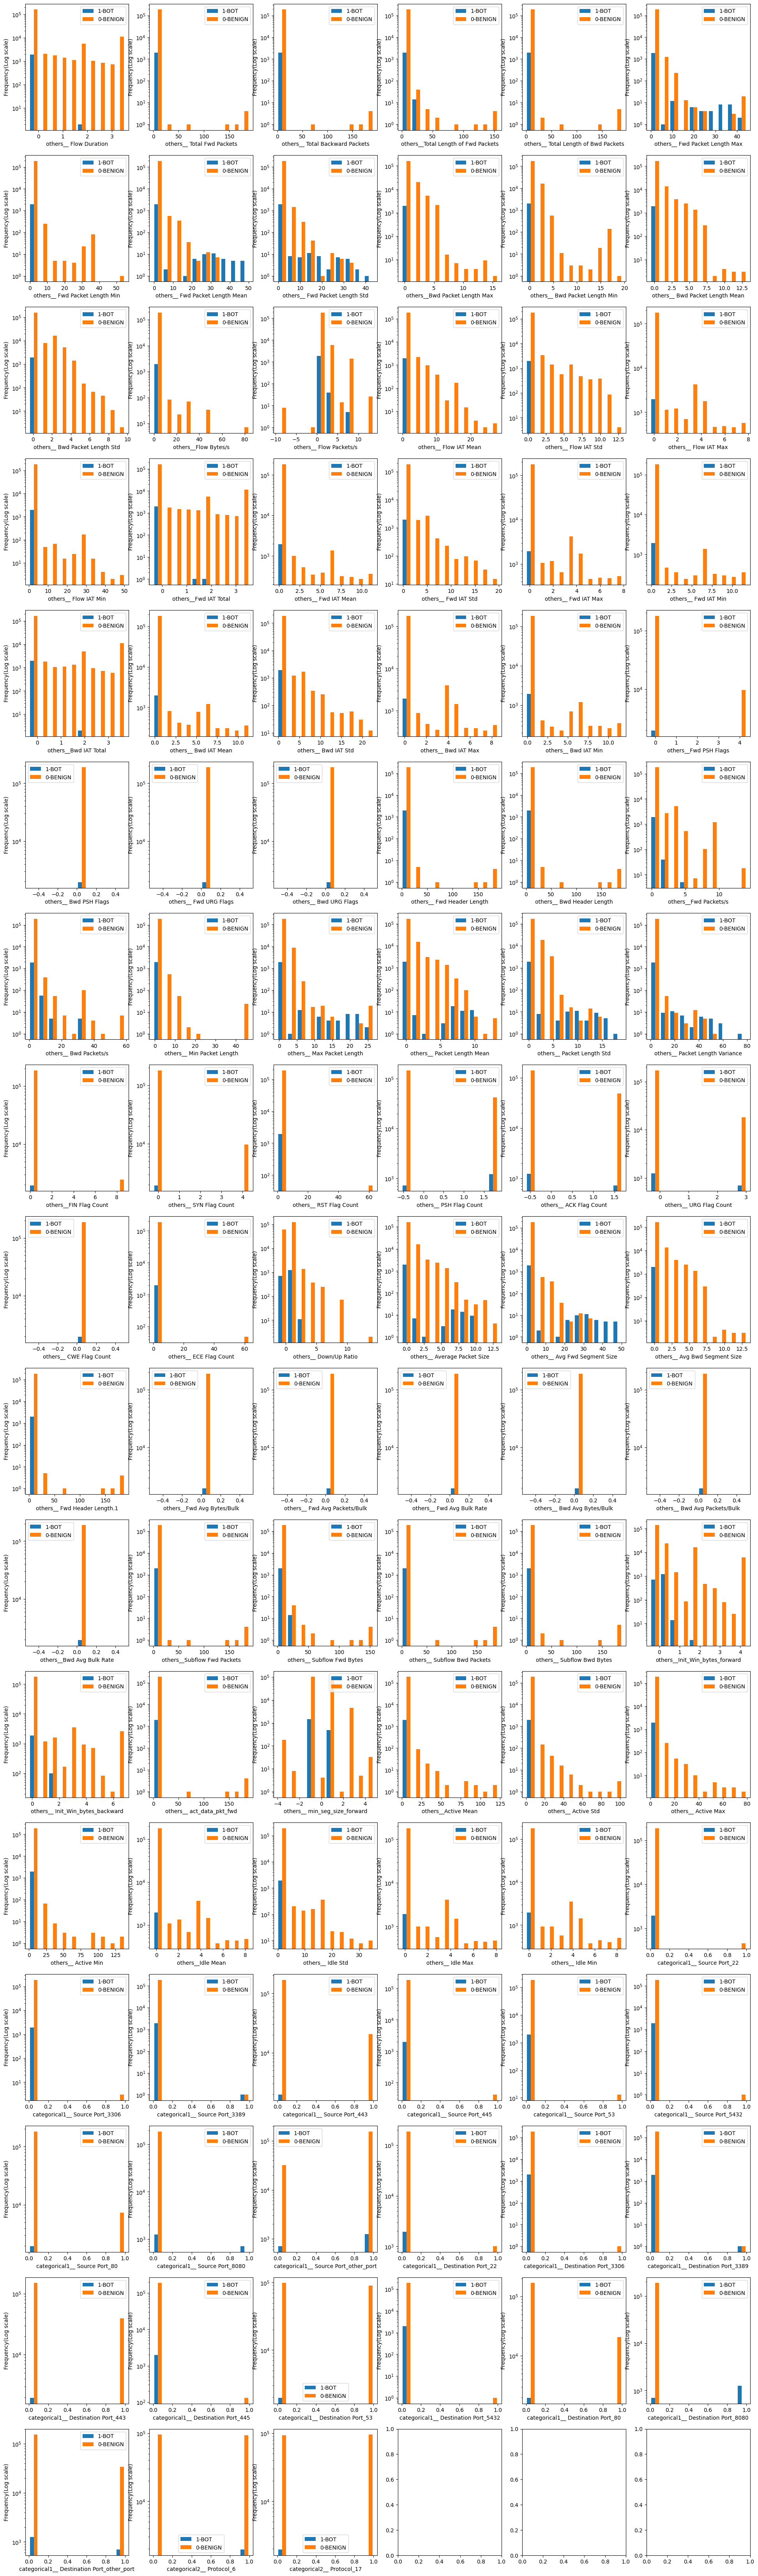

In [18]:
#use the encoded dataset to plot histogram
X_to_plot = df_X_2
plot_per_row = 6
n_rows = (len(X_to_plot.columns)+plot_per_row)//plot_per_row
plot_per_row = 6

_, ax = plt.subplots(nrows=n_rows, ncols=plot_per_row, figsize=(24, 5*n_rows))
cols = X_to_plot.columns
# Plot each feature of their own
for i,c in enumerate(cols):
    x = i%plot_per_row
    y = i//plot_per_row   
    ax[y,x].set_xlabel(c)
    ax[y,x].set_ylabel("Frequency(Log scale)")
    
    min = X_to_plot[c].min()
    max = X_to_plot[c].max()
    #ax[y,x].set_xticks([X[c].min(), X[c].max()])
    #ax[y,x].tick_params(axis='x', labelrotation=45)
    #ax[y,x].hist(X[c], bins=10, edgecolor='black',label=f"Min: {min:.2f}\nMax: {max:.2f}")
    ax[y,x].hist([X_to_plot[Y==1][c],X_to_plot[Y==0][c]], label=['1-BOT','0-BENIGN'])
    ax[y,x].set_yscale("log")
    ax[y,x].legend()

plt.show()

From the histogram above, many of the features shows that the BOT class focus on certain feature value ranges. For features like packet length, packet size and segment size, the distribution of BOT class is more wide, which could means that they are less informative for the learning model. But it would not be safe to pick some features now. Instead, it would be more benefitial to run a random forest classifer first to explore the feature importance.

### Question 7
#### 10-Fold CV performance of SVC, Random Forest Classifier and Neural network

In [19]:
def all_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'tpr':tp / (tp + fn),
            'fpr':fp / (fp + tn),
            'precision':tp / (fp + tp),
            'accu':(tp+tn)/(tp+tn+fp+fn),
            'f1':(2*tp)/(2*tp+fp+fn)}

def all_score_safe(y_true, y_pred):
    # Force a 2x2 matrix even if only 1 class is present
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    # Safe division to prevent divide by 0 on the single-class dataset
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accu = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    f1 = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    
    return {'tpr': tpr, 'fpr': fpr, 'precision': precision, 'accu': accu, 'f1': f1}


# 10-fold CV evaluation of a classifier on a pipeline
def eval_classifier_pipeline(pipeline, _X, _y):
    scores = {'tpr':[],
            'fpr':[],
            'precision':[],
            'accu':[],
            'f1':[]}
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        pipeline.fit(_X.iloc[train_index], _y.iloc[train_index])
        y_pred = pipeline.predict(_X.iloc[test_index])
        score = all_score_safe(_y.iloc[test_index], y_pred)
        for k in scores:
            scores[k].append(score[k])
    return scores

In [20]:
#calculate the CV performance on the whole data set with transform pipeline
#random forest
_clf = [RandomForestClassifier()]
#the other two models
_clf2 = [SVC(kernel='rbf'),
        neural_network.MLPClassifier(max_iter=300,random_state=42)]

CV_result = {}


In [21]:
#evaluate the forest first
pipe_forest = make_pipeline(preprocessor,_clf[0])
result = eval_classifier_pipeline(pipe_forest,X,Y)
CV_result.update({_clf[0].__class__.__name__:{k:[np.array(result[k]).mean(),np.array(result[k]).std()] for k in result}})

g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [22]:
#evaulate the other two
for c in _clf2:
    pipe_lr = make_pipeline(preprocessor,c)
    result = eval_classifier_pipeline(pipe_lr,X,Y)
    CV_result.update({c.__class__.__name__:{k:[np.array(result[k]).mean(),np.array(result[k]).std()] for k in result}})

g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories

In [24]:
#print out the 10-fold VC of the three models
for C in CV_result:
    print(f'{C} 10-fold CV accuracy:')
    for s in CV_result[C]:
        print(f'{s:10}:{CV_result[C][s][0]:.3f}{chr(177)}{CV_result[C][s][1]:.3f}')

RandomForestClassifier 10-fold CV accuracy:
tpr       :0.997±0.003
fpr       :0.000±0.000
precision :1.000±0.000
accu      :1.000±0.000
f1        :0.999±0.002
SVC 10-fold CV accuracy:
tpr       :0.991±0.006
fpr       :0.000±0.000
precision :0.999±0.002
accu      :1.000±0.000
f1        :0.995±0.004
MLPClassifier 10-fold CV accuracy:
tpr       :1.000±0.000
fpr       :0.000±0.000
precision :1.000±0.000
accu      :1.000±0.000
f1        :1.000±0.000


As seen from above printout, all three models performed quite well. Because the class are very unbalanced, TPR and F1 score would be more important. We can see that all three models give almost perfect TPR, from 0.991 to 1, as well as F1 score, from 0.995 to 1.

After that, I will attempt to reduce the features, with reference to random forest's feature importance score.

Top 15 Features:
 categorical1__ Source Port_8080         0.197563
categorical1__ Destination Port_8080    0.191388
others__Init_Win_bytes_forward          0.039909
categorical1__ Source Port_80           0.027720
others__ Bwd Packets/s                  0.027277
others__ Bwd IAT Min                    0.024103
others__ Flow Packets/s                 0.024062
others__ Fwd Header Length              0.022773
others__ Flow IAT Mean                  0.021835
categorical1__ Source Port_443          0.020167
others__ Init_Win_bytes_backward        0.019588
others__ Flow IAT Std                   0.016455
others__ Fwd Header Length.1            0.016360
others__ Subflow Bwd Bytes              0.016213
others__ Average Packet Size            0.016083
dtype: float64


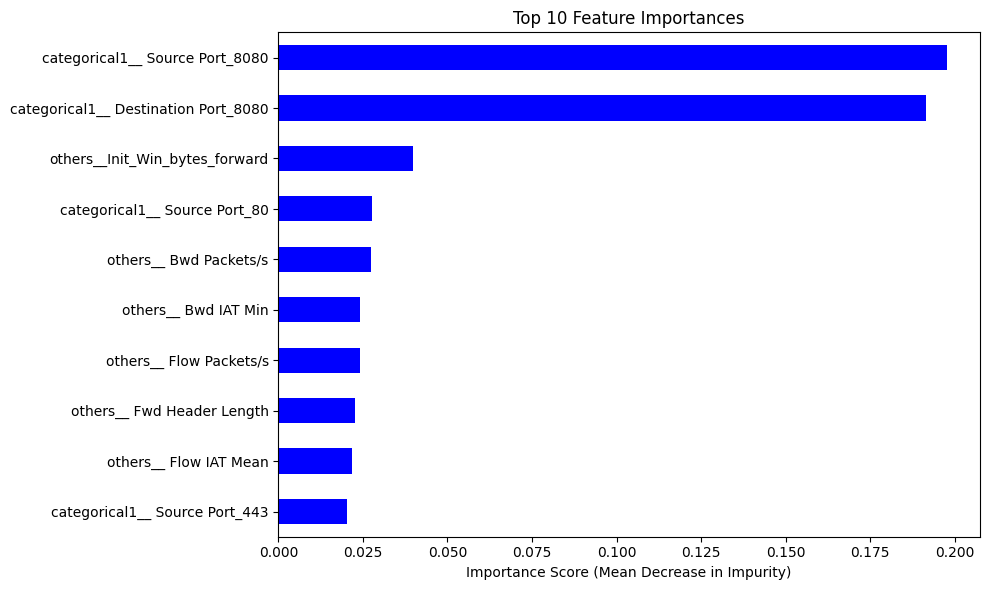

In [30]:
#extract the feature importance from the random forest
rf_model = pipe_forest[-1] 
importances = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

#build a series with the name and scores
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 15 Features:\n", importance_series.head(15))

# Plot top 10 of the results
plt.figure(figsize=(10, 6))
# Plotting top 10 for a cleaner chart
importance_series.head(10).plot.barh(color='blue')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score (Mean Decrease in Impurity)")
plt.gca().invert_yaxis() # Flips the Y-axis so the most important is at the top
plt.tight_layout()
plt.show()

As shown above, except the first two most important features, other features's importance are roughly similar. So try drop the bottom half of features according to importance.

In [28]:
#transform the dataset X
X_transformed = preprocessor.transform(X)

In [31]:
#create a new frame with transformed data
X_transformed_df = pd.DataFrame(X_transformed,columns=preprocessor.get_feature_names_out())
#use the top half of features according to importance
portion = 0.5
top_features = importance_series.head(len(X_transformed_df.columns)//2).index.tolist()
#filter
X_filtered = X_transformed_df[top_features]

print(f"Original shape: {X_transformed_df.shape}")
print(f"Filtered shape: {X_filtered.shape}")

#train another forest
new_CV_result = {}
#only the model because the filtered dataset is preprocessed
pipe_forest2 = make_pipeline(RandomForestClassifier())
result_2 = eval_classifier_pipeline(pipe_forest2,X_filtered,Y)

new_CV_result.update({RandomForestClassifier().__class__.__name__:{k:[np.array(result_2[k]).mean(),np.array(result_2[k]).std()] for k in result_2}})

Original shape: (190911, 99)
Filtered shape: (190911, 49)


In [32]:
for C in new_CV_result:
    print(f'{C}:')
    for s in CV_result[C]:
        print(f'{s}:10-fold CV accuracy:{CV_result[C][s][0]:.3f}{chr(177)}{CV_result[C][s][1]:.3f}')

RandomForestClassifier:
tpr:10-fold CV accuracy:0.997±0.003
fpr:10-fold CV accuracy:0.000±0.000
precision:10-fold CV accuracy:1.000±0.000
accu:10-fold CV accuracy:1.000±0.000
f1:10-fold CV accuracy:0.999±0.002


There is no difference on the result. Therefore, use the selected features for the rest.

### Question 8
#### Convert your code to be used for the remaining 7 datasets

In [33]:
#load all the data set
from pathlib import Path

dir = Path("dataset2to8")
file_paths = [str(f) for f in dir.rglob("*") if f.is_file()]

In [34]:
#function to consolidate all previously done transformation
def process_and_filter(file_path, fitted_preprocessor, raw_col_to_drop ,target_features):
    """
    Loads a new dataset, transforms it using the pre-fitted pipeline, 
    and filters it with the top_features from Dataset 1.
    """
    # new dataset
    new_data = pd.read_csv(file_path)

    #dropna
    new_data.dropna(inplace=True)
    #drop duplicate
    new_data.drop_duplicates(inplace=True)
    #drop inf
    new_data = new_data[~new_data.isin([float('inf'), float('-inf')]).any(axis=1)]
    
    # Separate X and y
    X_new = new_data.drop(columns=raw_col_to_drop)
    
    # Map the labels to 0 and 1
    y_new = new_data[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
    
    # Use the previous preprocessor to transform the features
    X_transformed_array = fitted_preprocessor.transform(X_new)
    
    # Convert to DataFrame with column names
    X_transformed_df = pd.DataFrame(X_transformed_array, columns=fitted_preprocessor.get_feature_names_out())
    
    # Filter the list of features from Dataset 1
    X_final = X_transformed_df[target_features]
    
    return X_final, y_new

#prepare each datasets
processed_datasets = {}
for file in file_paths:
    print(f"Dataset: {file}:")
    X_ready, Y_ready = process_and_filter(file, preprocessor, non_num_cols ,top_features)
    processed_datasets[file] = {'X': X_ready, 'Y': Y_ready}
    print(f"Finished. Shape: {X_ready.shape}")

Dataset: dataset2to8\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv:
Finished. Shape: (225709, 49)
Dataset: dataset2to8\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv:
Finished. Shape: (286095, 49)
Dataset: dataset2to8\Monday-WorkingHours.pcap_ISCX.csv:
Finished. Shape: (529450, 49)
Dataset: dataset2to8\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv:
Finished. Shape: (288253, 49)
Dataset: dataset2to8\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv:


C:\Users\shunf\AppData\Local\Temp\ipykernel_13176\4058781053.py:8: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  new_data = pd.read_csv(file_path)
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Finished. Shape: (170230, 49)
Dataset: dataset2to8\Tuesday-WorkingHours.pcap_ISCX.csv:
Finished. Shape: (445641, 49)
Dataset: dataset2to8\Wednesday-workingHours.pcap_ISCX.csv:
Finished. Shape: (691390, 49)


In [429]:
for f in processed_datasets:
    print(f,processed_datasets[f]['Y'].value_counts())

dataset2to8\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  Label
1    128025
0     97684
Name: count, dtype: int64
dataset2to8\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  Label
1    158804
0    127291
Name: count, dtype: int64
dataset2to8\Monday-WorkingHours.pcap_ISCX.csv  Label
0    529450
Name: count, dtype: int64
dataset2to8\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  Label
0    288217
1        36
Name: count, dtype: int64
dataset2to8\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  Label
0    168050
1      2180
Name: count, dtype: int64
dataset2to8\Tuesday-WorkingHours.pcap_ISCX.csv  Label
0    431809
1     13832
Name: count, dtype: int64
dataset2to8\Wednesday-workingHours.pcap_ISCX.csv  Label
0    439668
1    251722
Name: count, dtype: int64


The above are the functions and operation to preprocess and transform each dataset with the same condition as in previous questions and prepared it for evaluation under the same condition. Each dataset are now preprocessed and ready for next step.

### Question 9
####  evaluation for the remaining 7 datasets

The evaluation of the remaining datasets are divided into 2 parts. 

1. The first part is the 10-fold CV with neural network in the same parameter as in question 7.

2. The second part is using the model from question 7, to predict the class for each datasets.

In [35]:
paramsQ7 = _clf2[1].get_params()

In [431]:
#do individual 10-fold CV validation for each dataset
all_dataset_result_independent = {}
for i, file in enumerate(file_paths):
    nn = neural_network.MLPClassifier(**paramsQ7)
    nn_pipe = make_pipeline(nn)
    result_individual = eval_classifier_pipeline(nn_pipe,processed_datasets[file]['X'],processed_datasets[file]['Y'])
    all_dataset_result_independent[f"dataset{i}"] = {k:[np.array(result_individual[k]).mean(),np.array(result_individual[k]).std()] for k in result_individual}

In [432]:
#print results
for d in all_dataset_result_independent:
    print(f"{d} tpr: {all_dataset_result_independent[d]['tpr'][0]:.4f} F1 Score: {all_dataset_result_independent[d]['f1'][0]:.4f}")

dataset0 tpr: 0.9994 F1 Score: 0.9992
dataset1 tpr: 0.9993 F1 Score: 0.9996
dataset2 tpr: 0.0000 F1 Score: 0.0000
dataset3 tpr: 0.7500 F1 Score: 0.7406
dataset4 tpr: 0.9092 F1 Score: 0.8554
dataset5 tpr: 0.9876 F1 Score: 0.9775
dataset6 tpr: 0.9991 F1 Score: 0.9962


In [ ]:
from sklearn.cluster import DBSCAN
#use DBSCAN with eps=0.2 for dataset 2
epsilon = 0.2
db = DBSCAN(eps=epsilon)
db_y_pred = db.fit_predict(processed_datasets['dataset2to8\Monday-WorkingHours.pcap_ISCX.csv']['X'])

#count each clusters and the anomalies
cluster_counts = {str(i):len(db_y_pred[db_y_pred==i]) for i in np.unique(db_y_pred)}
resultdb=all_score_safe(processed_datasets['dataset2to8\Monday-WorkingHours.pcap_ISCX.csv']['Y'],db_y_pred)


In [ ]:
#refit the model of Q7 with all data in dataset1
nnQ7 = _clf2[1]
nnQ7.fit(X_filtered,Y)
all_dataset_result_Q7model = {}
for i, file in enumerate(file_paths):
    #test
    result = all_score_safe(processed_datasets[file]['Y'], nnQ7.predict(processed_datasets[file]['X']))
    all_dataset_result_Q7model[f"dataset{i}"] = result
    #print result
    print(f"Dataset {i}\n tpr: {result['tpr']:.4f} fpr: {result['fpr']:.4f} F1 Score: {result['f1']:.4f}")

Dataset 0
 tpr: 0.0000 F1 Score: 0.0000
Dataset 1
 tpr: 0.0010 F1 Score: 0.0020
Dataset 2
 tpr: 0.0000 F1 Score: 0.0000
Dataset 3
 tpr: 0.0000 F1 Score: 0.0000
Dataset 4
 tpr: 0.0000 F1 Score: 0.0000
Dataset 5
 tpr: 0.0000 F1 Score: 0.0000
Dataset 6
 tpr: 0.0000 F1 Score: 0.0000


The first part of 10-fold CV results shows that the neural network model with selected features work wells on each of dataset, as we can observe a good range of TPR from 0.75 to 0.99 and F1 score from 0.74 to 0.99.

As for Dataset 2 , as it only contain 1 single class, I tried to evaluate it differently with DBSCAN, but the kernel failed multiple times, probably because of the size and scale of data so its CV result is not available.

However, when I applied the trained model from question 7 to each of the dataset directly, it is complete failure, which indicated that different datasets are completely non-comparable and belonged to completely different scenarios.

### Question 10

Using the example in this assignment, the biggest challenge I faced is that I am not familiar with each of the feature's nature and purpose, which means that I would lack common sense to tell if the raw data are rational. 
I then have to rely on very objective standard for feature selection if I want to improve the model. It sounds not ideal, because I could miss some important processing and transformation that might benefit the training. 

Another more important problem is that I might miss the whole point of training, by applying the model trained with a particular type of attack to another use case, because I am not aware of that fact that there are many different type of attacks and they require different detection models. It is well illustrated when I tried to apply the model trained with dataset 1 to the other datasets and the result is catastrophic.

However, on the other hand, it would also mean I am not bound to the trap of being subjective to the data and result as if I know too much. I could therefore give the most objective opinions from the outsider's point of view.